In [1]:
"""
Proyecto #2 — Sistema Generativo Interactivo (UTEC)
Tema: Auditoría de Desinformación Visual y Deepfakes

Rol de este script (puntos 3.1 / 3.2): EDA + preparación de datos del
Human Faces Dataset (Real vs AI-Generated) para entrenar el CLASIFICADOR
FORENSE que asigna un score de autenticidad a cada variación generada
por el módulo de 3.3. El usuario ve la variación + su score y decide
aceptar/rechazar; el agente LLM (3.5) explica la decisión combinando
ambas señales.
"""
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm

from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# ==========================================
# FASE 1: EXTRACCIÓN Y LIMPIEZA
# ==========================================
print("--- FASE 1: LIMPIEZA DE DATOS ---")
base_path = '/kaggle/input/datasets/kaustubhdhote/human-faces-dataset/Human Faces Dataset'
real_path = os.path.join(base_path, 'Real Images')
fake_path = os.path.join(base_path, 'AI-Generated Images')

def get_clean_data(directory, label, max_samples=2000):
    valid_paths = []
    for filename in tqdm(os.listdir(directory)[:max_samples], desc=f"Procesando {label}"):
        filepath = os.path.join(directory, filename)
        if filepath.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                with Image.open(filepath) as img:
                    img.verify()
                valid_paths.append({'filepath': filepath, 'label': label})
            except Exception:
                pass
    return valid_paths

data_real = get_clean_data(real_path, 'Real')
data_fake = get_clean_data(fake_path, 'Fake_AI')
df = pd.DataFrame(data_real + data_fake)

print(f"\nTotal imágenes válidas: {len(df)}")
print(df['label'].value_counts())

--- FASE 1: LIMPIEZA DE DATOS ---


Procesando Fake_AI: 100%|██████████| 2000/2000 [00:15<00:00, 125.47it/s]


Total imágenes válidas: 4000
label
Real       2000
Fake_AI    2000
Name: count, dtype: int64


# Análisis Exploratorio (EDA)

In [13]:
FIGURES_DIR = '/kaggle/working/figuras'
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# ==========================================
# FASE 2: ANÁLISIS EXPLORATORIO (EDA) PROFUNDO
# ==========================================
print("\n--- FASE 2: ANÁLISIS EXPLORATORIO ---")

# --------------------------------------------------------------
# 2.1 Extracción de características (consolidada en una sola pasada
#     por imagen, para no abrir cada archivo dos veces)
# --------------------------------------------------------------
def extract_full_features(row):
    path = row['filepath']
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # --- Color ---
    r_mean, g_mean, b_mean = np.mean(img_rgb, axis=(0, 1))
    r_std, g_std, b_std = np.std(img_rgb, axis=(0, 1))
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    sat_mean = np.mean(hsv[:, :, 1])

    # --- Nitidez / textura (proxy de artefactos de generación) ---
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

    # --- Densidad de bordes ---
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    # --- Tamaño de archivo / compresión (proxy de origen cámara vs IA) ---
    file_size_kb = os.path.getsize(path) / 1024
    bytes_per_pixel = os.path.getsize(path) / (w * h)

    # --- Relación alta/baja frecuencia (proxy artefactos del generador) ---
    gray_small = cv2.resize(gray, (256, 256))
    f = np.fft.fftshift(np.fft.fft2(gray_small))
    mag = np.abs(f)
    Y, X = np.ogrid[:256, :256]
    r = np.sqrt((X - 128) ** 2 + (Y - 128) ** 2)
    high_freq_energy = mag[r > 90].mean()
    low_freq_energy = mag[r <= 20].mean()
    hf_lf_ratio = high_freq_energy / (low_freq_energy + 1e-6)

    return pd.Series({
        'width': w, 'height': h, 'aspect_ratio': w / h,
        'R_mean': r_mean, 'G_mean': g_mean, 'B_mean': b_mean,
        'R_std': r_std, 'G_std': g_std, 'B_std': b_std,
        'saturation_mean': sat_mean,
        'sharpness_laplacian': sharpness,
        'edge_density': edge_density,
        'file_size_kb': file_size_kb,
        'bytes_per_pixel': bytes_per_pixel,
        'hf_lf_ratio': hf_lf_ratio
    })

tqdm.pandas(desc="Extrayendo características")
feature_cols = ['width', 'height', 'aspect_ratio', 'R_mean', 'G_mean', 'B_mean',
                 'R_std', 'G_std', 'B_std', 'saturation_mean', 'sharpness_laplacian',
                 'edge_density', 'file_size_kb', 'bytes_per_pixel', 'hf_lf_ratio']
df[feature_cols] = df.progress_apply(extract_full_features, axis=1)

print("\n[INFO] Resoluciones únicas encontradas:")
print(df.groupby(['label', 'width', 'height']).size().reset_index(name='cantidad'))


--- FASE 2: ANÁLISIS EXPLORATORIO ---


Extrayendo características: 100%|██████████| 4000/4000 [00:36<00:00, 110.37it/s]


[INFO] Resoluciones únicas encontradas:
     label  width  height  cantidad
0  Fake_AI  256.0   256.0      2000
1     Real  178.0   218.0      2000


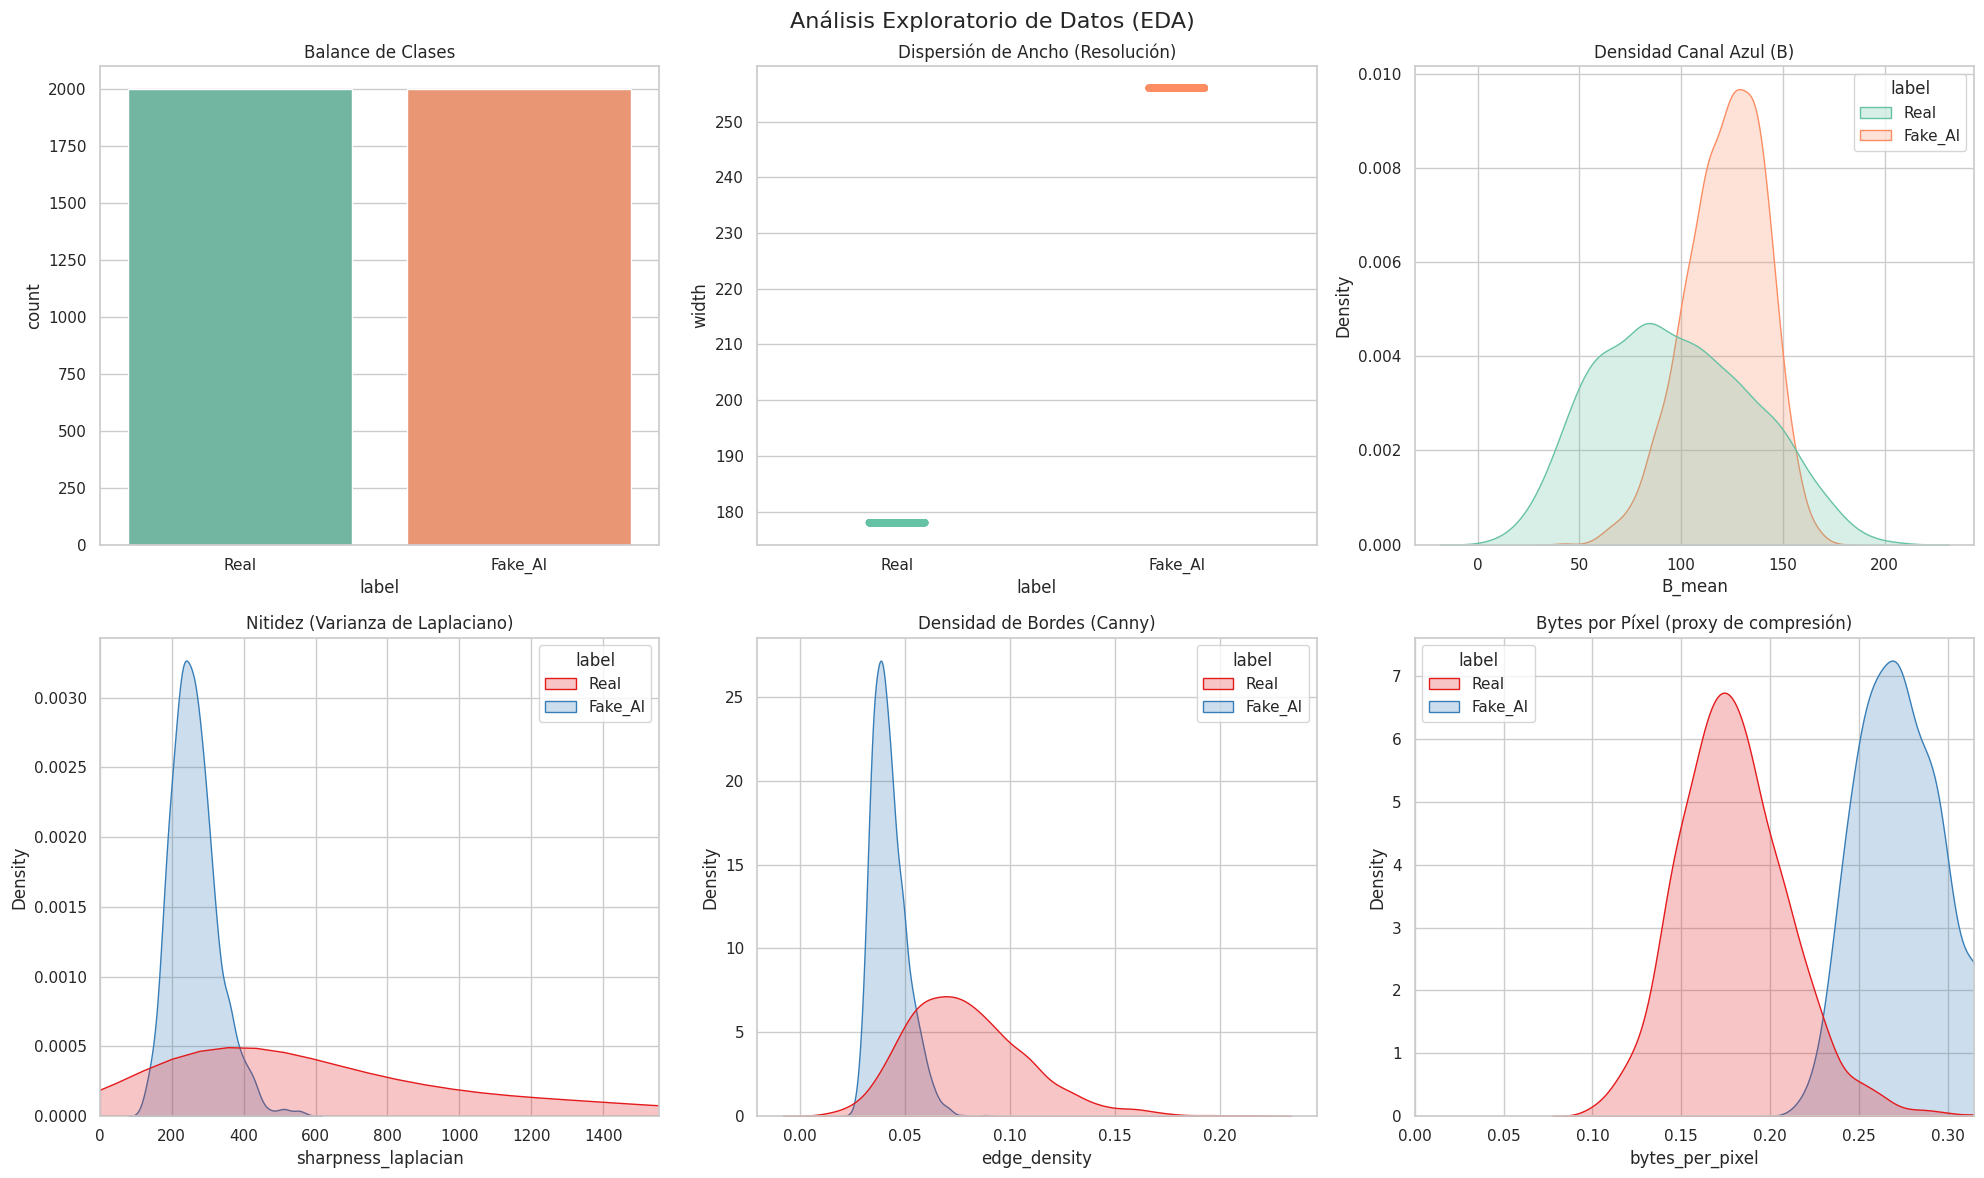

In [14]:
# --------------------------------------------------------------
# 2.2 Gráficas estadísticas (las originales + nuevas)
# --------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Análisis Exploratorio de Datos (EDA)', fontsize=16)

sns.countplot(data=df, x='label', hue='label', palette='Set2', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Balance de Clases')

sns.stripplot(data=df, x='label', y='width', hue='label', palette='Set2', jitter=True,
              alpha=0.6, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Dispersión de Ancho (Resolución)')

sns.kdeplot(data=df, x='B_mean', hue='label', fill=True, palette='Set2', ax=axes[0, 2])
axes[0, 2].set_title('Densidad Canal Azul (B)')

# --- Nuevas: nitidez, bordes y compresión, que son las que más
#     se relacionan con artefactos de generación IA ---
sns.kdeplot(data=df, x='sharpness_laplacian', hue='label', fill=True, palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('Nitidez (Varianza de Laplaciano)')
axes[1, 0].set_xlim(0, df['sharpness_laplacian'].quantile(0.95))

sns.kdeplot(data=df, x='edge_density', hue='label', fill=True, palette='Set1', ax=axes[1, 1])
axes[1, 1].set_title('Densidad de Bordes (Canny)')

sns.kdeplot(data=df, x='bytes_per_pixel', hue='label', fill=True, palette='Set1', ax=axes[1, 2])
axes[1, 2].set_title('Bytes por Píxel (proxy de compresión)')
axes[1, 2].set_xlim(0, df['bytes_per_pixel'].quantile(0.95))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_distribuciones_eda.png'), dpi=150, bbox_inches='tight')
plt.show()

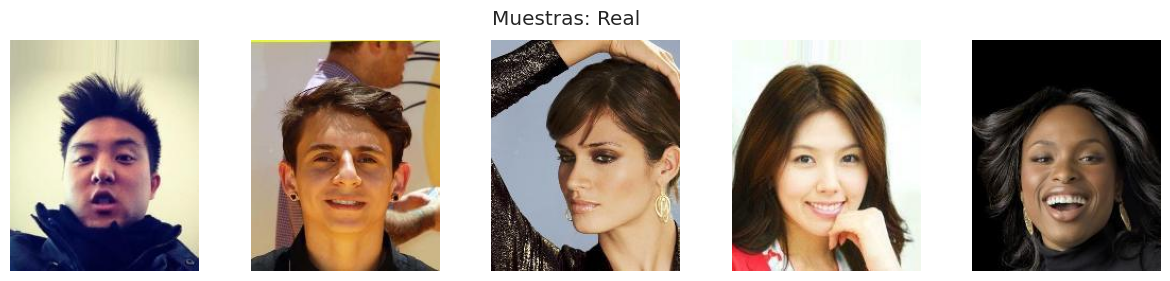

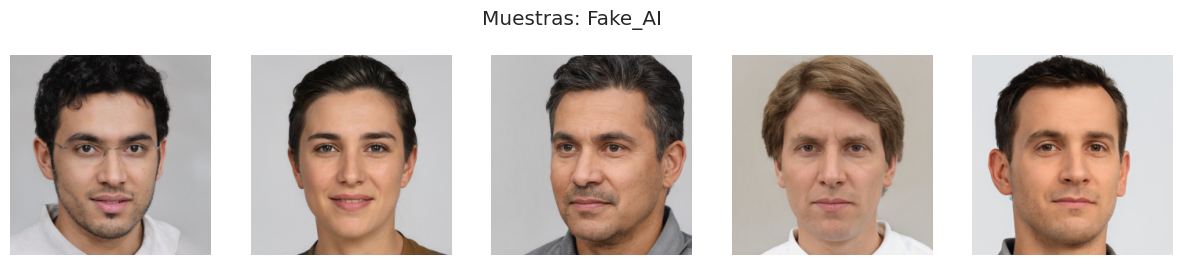

In [17]:
# --------------------------------------------------------------
# 2.3 Muestras visuales por clase (evidencia cualitativa para el informe)
# --------------------------------------------------------------
def show_sample_grid(data, label, n=5, save_name=None):
    samples = data[data.label == label].sample(n, random_state=1)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, path in zip(axes, samples['filepath']):
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
    fig.suptitle(f'Muestras: {label}')
    if save_name:
        plt.savefig(os.path.join(FIGURES_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()

show_sample_grid(df, 'Real', save_name='02_muestras_real.png')
show_sample_grid(df, 'Fake_AI', save_name='03_muestras_fake_ai.png')


Generando perfil radial de frecuencia promedio (Real vs IA)...


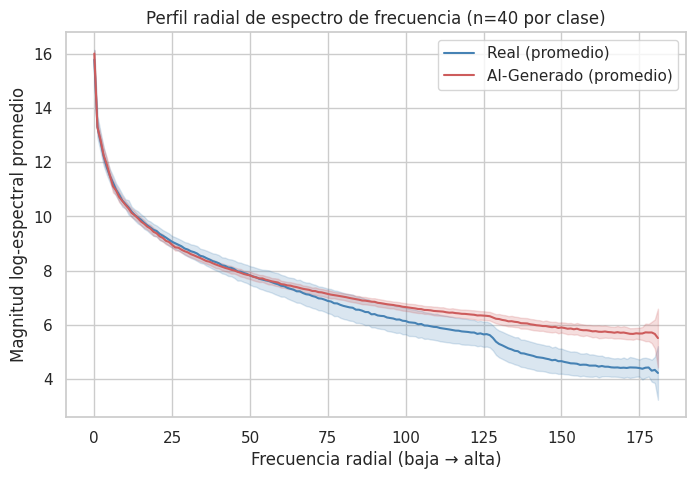

In [18]:
# --------------------------------------------------------------
# 2.4 Análisis del dominio de frecuencia — perfil radial PROMEDIO
#     (más robusto que comparar una sola imagen por clase)
# --------------------------------------------------------------
def radial_profile(mag, center=None):
    y, x = np.indices(mag.shape)
    if center is None:
        center = (mag.shape[1] // 2, mag.shape[0] // 2)
    r = np.sqrt((x - center[0]) ** 2 + (y - center[1]) ** 2).astype(int)
    tbin = np.bincount(r.ravel(), mag.ravel())
    nr = np.bincount(r.ravel())
    return tbin / (nr + 1e-6)

def compute_radial_profiles(subset_df, n_samples=40, size=256):
    sample = subset_df.sample(min(n_samples, len(subset_df)), random_state=42)
    profiles = []
    for path in sample['filepath']:
        gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        gray = cv2.resize(gray, (size, size))
        f = np.fft.fftshift(np.fft.fft2(gray))
        mag = np.log(np.abs(f) + 1)
        profiles.append(radial_profile(mag))
    max_len = max(len(p) for p in profiles)
    profiles = [np.pad(p, (0, max_len - len(p))) for p in profiles]
    return np.array(profiles)

print("\nGenerando perfil radial de frecuencia promedio (Real vs IA)...")
profiles_real = compute_radial_profiles(df[df.label == 'Real'])
profiles_fake = compute_radial_profiles(df[df.label == 'Fake_AI'])

plt.figure(figsize=(8, 5))
x_axis = range(profiles_real.shape[1])
plt.plot(profiles_real.mean(axis=0), label='Real (promedio)', color='steelblue')
plt.fill_between(x_axis, profiles_real.mean(axis=0) - profiles_real.std(axis=0),
                  profiles_real.mean(axis=0) + profiles_real.std(axis=0), alpha=0.2, color='steelblue')
plt.plot(profiles_fake.mean(axis=0), label='AI-Generado (promedio)', color='indianred')
plt.fill_between(x_axis, profiles_fake.mean(axis=0) - profiles_fake.std(axis=0),
                  profiles_fake.mean(axis=0) + profiles_fake.std(axis=0), alpha=0.2, color='indianred')
plt.xlabel('Frecuencia radial (baja → alta)')
plt.ylabel('Magnitud log-espectral promedio')
plt.title(f'Perfil radial de espectro de frecuencia (n={profiles_real.shape[0]} por clase)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, '04_perfil_frecuencia_radial.png'), dpi=150, bbox_inches='tight')
plt.show()

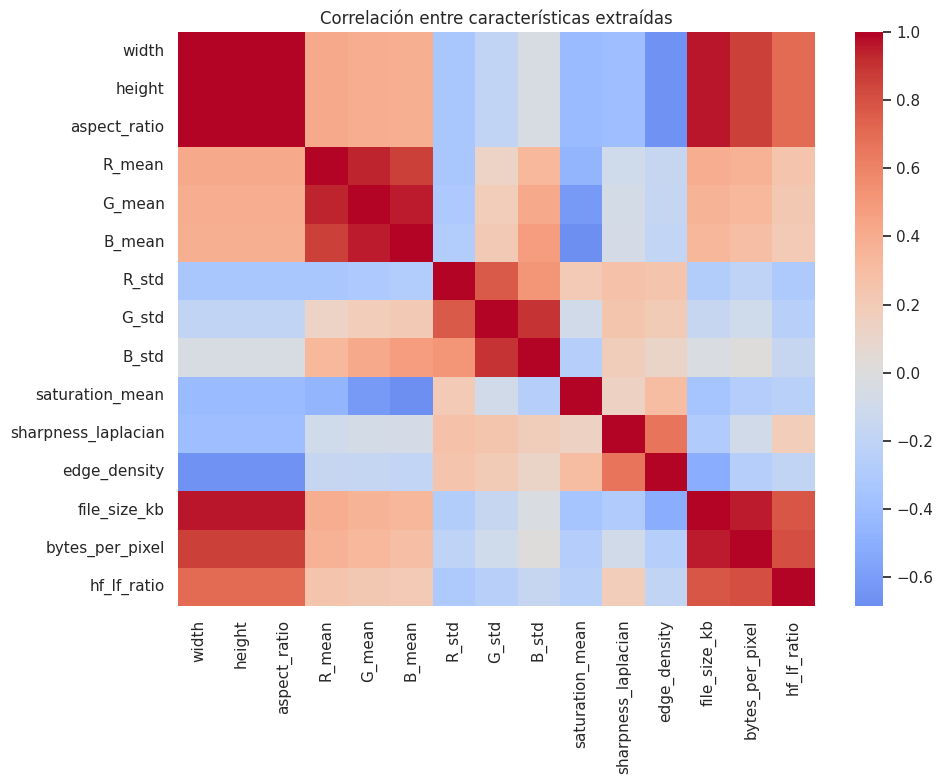

In [20]:
# --------------------------------------------------------------
# 2.5 Correlación entre características y reducción de dimensionalidad
# --------------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlación entre características extraídas')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_correlacion_features.png'), dpi=150, bbox_inches='tight')
plt.show()

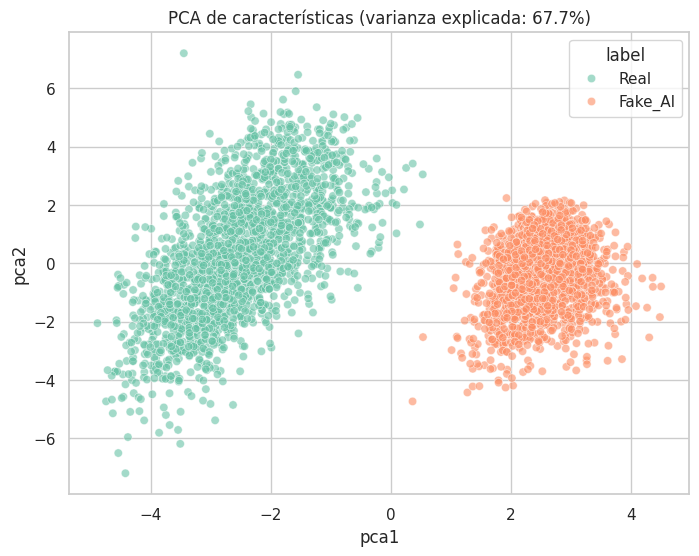

In [22]:
X_scaled = StandardScaler().fit_transform(df[feature_cols].fillna(0))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca1'], df['pca2'] = X_pca[:, 0], X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='label', palette='Set2', alpha=0.6)
plt.title(f'PCA de características (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})')
plt.savefig(os.path.join(FIGURES_DIR, '06_pca_features.png'), dpi=150, bbox_inches='tight')
plt.show()

Calculando t-SNE sobre una submuestra (puede tardar un poco)...


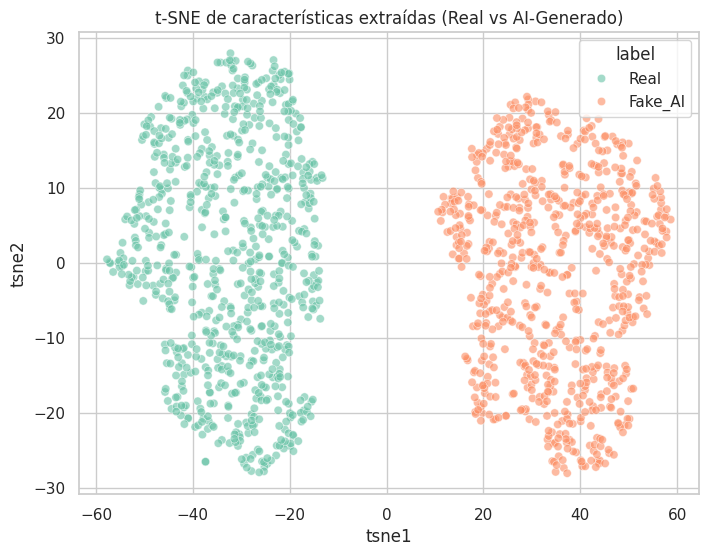

In [23]:
print("Calculando t-SNE sobre una submuestra (puede tardar un poco)...")
subsample = df.sample(min(1500, len(df)), random_state=42)
X_sub = StandardScaler().fit_transform(subsample[feature_cols].fillna(0))
X_tsne = TSNE(n_components=2, random_state=42, init='pca', perplexity=30).fit_transform(X_sub)
subsample = subsample.copy()
subsample['tsne1'], subsample['tsne2'] = X_tsne[:, 0], X_tsne[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=subsample, x='tsne1', y='tsne2', hue='label', palette='Set2', alpha=0.6)
plt.title('t-SNE de características extraídas (Real vs AI-Generado)')
plt.savefig(os.path.join(FIGURES_DIR, '07_tsne_features.png'), dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# --------------------------------------------------------------
# 2.6 Significancia estadística por característica (Mann-Whitney U)
#     -> qué señales separan realmente lo auténtico de lo fabricado
# --------------------------------------------------------------
results = []
for col in feature_cols:
    real_vals = df.loc[df.label == 'Real', col]
    fake_vals = df.loc[df.label == 'Fake_AI', col]
    stat, p = mannwhitneyu(real_vals, fake_vals, alternative='two-sided')
    results.append({
        'feature': col,
        'media_real': real_vals.mean(),
        'media_fake': fake_vals.mean(),
        'p_value': p
    })

stats_df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
print("\n[Significancia estadística Real vs Fake_AI — Mann-Whitney U]")
print(stats_df.to_string(index=False))


[Significancia estadística Real vs Fake_AI — Mann-Whitney U]
            feature  media_real  media_fake       p_value
              width  178.000000  256.000000  0.000000e+00
             height  218.000000  256.000000  0.000000e+00
       aspect_ratio    0.816514    1.000000  0.000000e+00
       edge_density    0.079438    0.042322  0.000000e+00
       file_size_kb    6.799073   17.673254  0.000000e+00
    bytes_per_pixel    0.179421    0.276145  0.000000e+00
        hf_lf_ratio    0.008120    0.013413  0.000000e+00
sharpness_laplacian  765.308144  263.228756 9.176711e-238
    saturation_mean   91.709315   67.208147 6.683312e-145
             R_mean  128.730771  156.323739 5.726012e-138
             G_mean  108.090447  133.650380 6.557658e-127
             B_mean   96.927779  121.724525 1.159632e-120
              R_std   67.654153   59.298905  1.863364e-97
              G_std   62.607324   57.897192  2.689579e-22
              B_std   61.388748   60.093899  3.820505e-01


In [25]:

# ==========================================
# FASE 3: PREPARACIÓN DE DATOS PARA EL CLASIFICADOR FORENSE
# ==========================================
# Contexto del sistema (ver definición de problema, 3.1):
#   El usuario sube un rostro real -> el módulo generativo (3.3) crea 5
#   variaciones -> a cada variación se le asigna un SCORE DE AUTENTICIDAD
#   producido por un clasificador real-vs-IA entrenado con este dataset
#   -> el usuario acepta/rechaza viendo imagen + score -> el agente LLM
#   (3.5) redacta el reporte de auditoría combinando ambas señales.
#
# Esta fase prepara los datos para ESE clasificador, con dos cuidados:
#   1) Reservar una "pool de demo" que el clasificador NUNCA vea en
#      entrenamiento/validación/test, para usarla luego como las imágenes
#      de ejemplo que el usuario "sube" en la interfaz (etapa 3.4).
#   2) Split estratificado real, no un sample() simple.
print("\n--- FASE 3: PREPARACIÓN DE DATOS ---")

DEMO_POOL_REAL = 40   # caso normal: el usuario sube una foto auténtica
DEMO_POOL_FAKE = 10   # caso límite: el usuario sube, sin saberlo, una imagen ya generada por IA

demo_real = df[df.label == 'Real'].sample(DEMO_POOL_REAL, random_state=7)
demo_fake = df[df.label == 'Fake_AI'].sample(DEMO_POOL_FAKE, random_state=7)
demo_pool_df = pd.concat([demo_real, demo_fake]).reset_index(drop=True)

# Todo lo que NO está en la pool de demo es lo que entrena/valida/prueba
# el clasificador forense.
classifier_df = df.drop(index=demo_real.index).drop(index=demo_fake.index).reset_index(drop=True)

print(f"Pool de demo (reservada, no la ve el clasificador): {len(demo_pool_df)} imágenes "
      f"({DEMO_POOL_REAL} reales / {DEMO_POOL_FAKE} IA)")
print(f"Datos disponibles para el clasificador forense: {len(classifier_df)} imágenes")
print(classifier_df['label'].value_counts())


--- FASE 3: PREPARACIÓN DE DATOS ---
Pool de demo (reservada, no la ve el clasificador): 50 imágenes (40 reales / 10 IA)
Datos disponibles para el clasificador forense: 3950 imágenes
label
Fake_AI    1990
Real       1960
Name: count, dtype: int64


In [26]:
class ProyectoDataset(Dataset):
    def __init__(self, df_subset, transform=None):
        self.df = df_subset.reset_index(drop=True)
        self.transform = transform
        self.label_map = {'Real': 1, 'Fake_AI': 0}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['filepath']).convert("RGB")
        label = self.label_map[self.df.iloc[idx]['label']]
        if self.transform:
            img = self.transform(img)
        return img, label

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])

eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])

In [27]:
# Split ESTRATIFICADO 70/15/15 sobre classifier_df (la pool de demo queda
# completamente fuera de este proceso).
train_df, temp_df = train_test_split(classifier_df, test_size=0.30,
                                      stratify=classifier_df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50,
                                    stratify=temp_df['label'], random_state=42)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{name} -> ", split['label'].value_counts(normalize=True).round(3).to_dict())

train_dataset = ProyectoDataset(train_df, transform=train_transforms)
val_dataset = ProyectoDataset(val_df, transform=eval_transforms)
test_dataset = ProyectoDataset(test_df, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Train: 2765 | Val: 592 | Test: 593
Train ->  {'Fake_AI': 0.504, 'Real': 0.496}
Val ->  {'Fake_AI': 0.503, 'Real': 0.497}
Test ->  {'Fake_AI': 0.504, 'Real': 0.496}


In [28]:
# --------------------------------------------------------------
# Exportar todo lo que necesitan los siguientes pasos del proyecto
# --------------------------------------------------------------
df.to_csv('/kaggle/working/metadata_eda.csv', index=False)
stats_df.to_csv('/kaggle/working/significancia_features.csv', index=False)

# Splits del clasificador (para que 3.3 los cargue sin tener que rehacer todo este pipeline)
train_df[['filepath', 'label']].to_csv('/kaggle/working/clasificador_train.csv', index=False)
val_df[['filepath', 'label']].to_csv('/kaggle/working/clasificador_val.csv', index=False)
test_df[['filepath', 'label']].to_csv('/kaggle/working/clasificador_test.csv', index=False)

# Pool de demo para la interfaz (3.4): imágenes que el usuario "sube" en la demo
demo_pool_df[['filepath', 'label']].to_csv('/kaggle/working/demo_pool_interfaz.csv', index=False)

print("\n¡Listo! DataLoaders del clasificador forense creados (train/val/test estratificados),")
print("pool de demo reservada para la interfaz, y todos los CSV exportados a /kaggle/working/.")


¡Listo! DataLoaders del clasificador forense creados (train/val/test estratificados),
pool de demo reservada para la interfaz, y todos los CSV exportados a /kaggle/working/.
